# Explore here

In [9]:
!pip install pandas matplotlib statsmodels pmdarima scikit-learn

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 61.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 698.0/698.0 kB 57.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 42.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 71.1 MB/s eta 0:00:00:00:01

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [10]:
import pandas as pd

url = ("https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv")

total_data = pd.read_csv(url)

total_data.head()

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


In [11]:
# (Ajusta los nombres si el CSV tiene otros)
df = total_data.copy()
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

# Ordenar el índice cronológicamente (muy importante en series temporales)
df = df.sort_index()

print(df.head())

                                sales
date                                 
2022-09-03 17:10:08.079328  55.292157
2022-09-04 17:10:08.079328  53.803211
2022-09-05 17:10:08.079328  58.141693
2022-09-06 17:10:08.079328  64.530899
2022-09-07 17:10:08.079328  66.013633


#Construye y analiza la serie temporal

Para responder a las preguntas, necesitamos visualizar la serie, descomponerla en sus componentes principales y aplicar una prueba estadística (como el test de Dickey-Fuller aumentado) para comprobar la estacionariedad

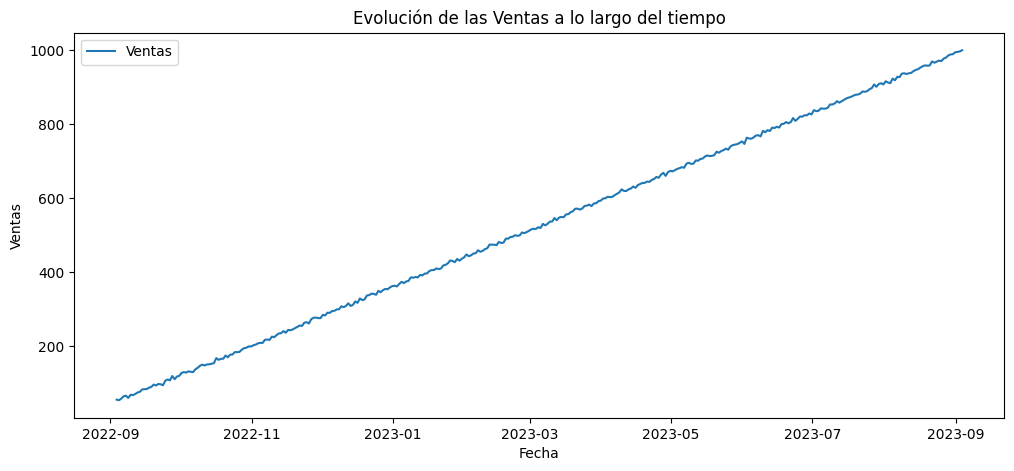

El tensor de la serie temporal es: 1 days 00:00:00


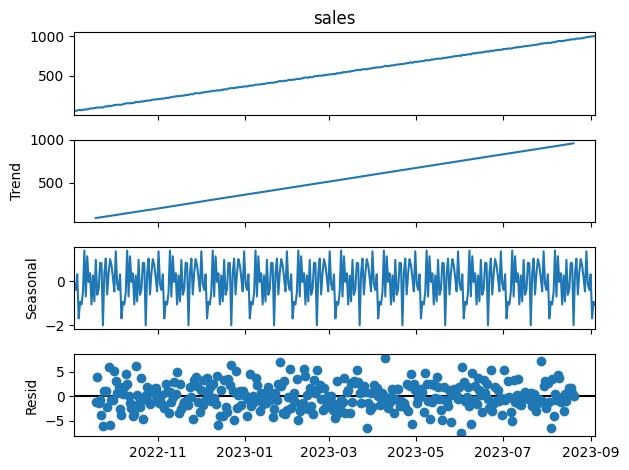

P-valor del test ADF: 0.9861899815311064
La serie NO es estacionaria.


In [13]:
import matplotlib.pyplot as plt


from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# 1. Graficar la serie temporal
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['sales'], label='Ventas')
plt.title('Evolución de las Ventas a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.show()

# 2. Encontrar el "tensor" (frecuencia de los datos)
frecuencia = df.index.to_series().diff().value_counts().idxmax()
print(f"El tensor de la serie temporal es: {frecuencia}")

# 3. Descomponer la serie (Tendencia, Estacionalidad, Ruido/Residuo)
# Ajusta el 'period' según el tensor (ej. 30 para datos diarios con patrón mensual)
descomposicion = seasonal_decompose(df['sales'], model='additive', period=30)
descomposicion.plot()
plt.show()

# 4. Prueba de Estacionariedad (Test de Dickey-Fuller)
resultado_adf = adfuller(df['sales'])
print(f'P-valor del test ADF: {resultado_adf[1]}')
if resultado_adf[1] < 0.05:
    print("La serie ES estacionaria.")
else:
    print("La serie NO es estacionaria.")

#¿Cuál es el tensor de la serie temporal?
 El código te lo dirá exactamente, pero revisará la diferencia entre filas. Si hay un dato por día, el tensor es diario (1 día).

#¿Cuál es la tendencia?
("ha ido en aumento"), la gráfica mostrará una tendencia alcista (creciente).

#¿Es estacionaria?
 No. Una serie con una clara tendencia creciente (su media cambia con el tiempo) no es estacionaria. El P-valor del test ADF seguramente será mayor a 0.05, confirmándolo.

#¿Existe variabilidad o presencia de ruido?
 Sí. Al observar la gráfica de "Resid (Residuos)" en la descomposición, verás fluctuaciones aleatorias que no pueden ser explicadas ni por la tendencia ni por la estacionalidad (ruido).

#Entrena un ARIMA

Para encontrar la mejor parametrización $(p, d, q)$ sin tener que hacer ensayo y error manual observando los gráficos de autocorrelación (ACF/PACF), lo mejor es utilizar la función auto_arima de la librería pmdarima.

In [14]:
import pmdarima as pm

# Dividir en conjunto de entrenamiento y prueba (ej. 80% train, 20% test)
# En series temporales NO se pueden barajar los datos, se cortan cronológicamente
split_point = int(len(df) * 0.8)
train = df.iloc[:split_point]
test = df.iloc[split_point:]

print(f"Tamaño Train: {len(train)}, Tamaño Test: {len(test)}")

# Entrenar el modelo Auto-ARIMA para buscar los mejores parámetros
# trace=True te mostrará el proceso de búsqueda en la consola
modelo_arima = pm.auto_arima(train['sales'], 
                             start_p=1, start_q=1,
                             test='adf',       # usa adftest para encontrar la 'd' óptima
                             max_p=5, max_q=5, # máximo p y q
                             m=1,              # frecuencia de la serie (1 si no hay estacionalidad clara, o cámbialo a 12 para meses, etc.)
                             d=None,           # deja que el modelo determine 'd'
                             seasonal=False,   # pon True si detectaste estacionalidad anual/mensual clara
                             trace=True,
                             error_action='ignore',  
                             suppress_warnings=True, 
                             stepwise=True)

print(modelo_arima.summary())

Tamaño Train: 292, Tamaño Test: 74
Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=1780.451, Time=0.37 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=4437.996, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.05 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.20 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=1748.437, Time=0.24 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=inf, Time=0.12 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=1547.133, Time=0.28 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=1774.837, Time=0.25 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.31 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=1730.844, Time=0.19 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=1782.007, Time=0.34 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=0.36 sec
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=1785.394, Time=0.53 sec

Best model:  ARIMA(2,0,2)(0

#Predice con el conjunto de test

Ahora validaremos qué tan bueno es nuestro modelo comparando sus predicciones con el trozo de datos que apartamos (Test).

Error Cuadrático Medio (MSE): 1223.12
Raíz del Error Cuadrático Medio (RMSE): 34.97
Error Absoluto Medio (MAE): 26.93


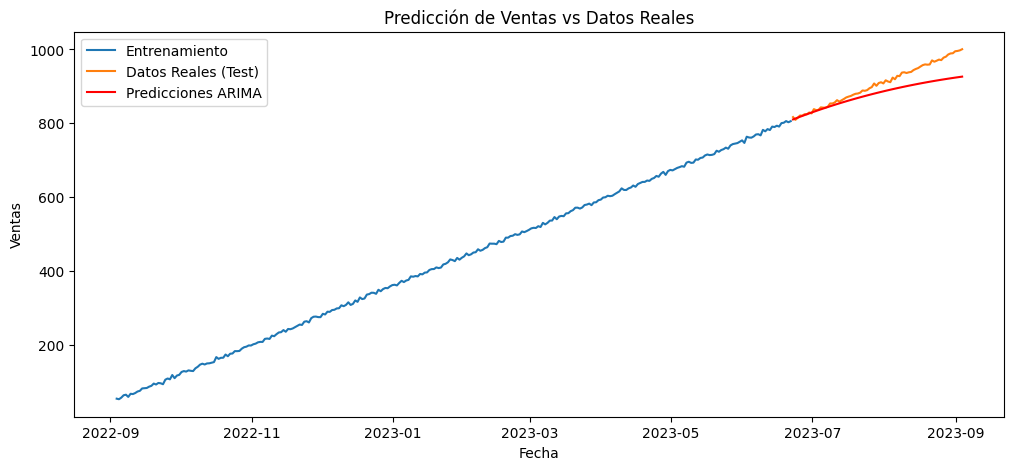

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Realizar predicciones sobre el periodo de test
predicciones = modelo_arima.predict(n_periods=len(test))
# Asegurarnos de que las predicciones compartan el índice temporal de los datos de prueba
predicciones.index = test.index

# Calcular métricas de rendimiento
mse = mean_squared_error(test['sales'], predicciones)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test['sales'], predicciones)

print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")
print(f"Error Absoluto Medio (MAE): {mae:.2f}")

# Visualizar Realidad vs Predicción
plt.figure(figsize=(12, 5))
plt.plot(train.index, train['sales'], label='Entrenamiento')
plt.plot(test.index, test['sales'], label='Datos Reales (Test)')
plt.plot(test.index, predicciones, color='red', label='Predicciones ARIMA')
plt.title('Predicción de Ventas vs Datos Reales')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.show()

#Guarda el modelo

In [16]:
import pickle
import os

# Crear la carpeta 'models' si no existe
if not os.path.exists('models'):
    os.makedirs('models')

# Ruta donde se guardará el modelo
ruta_modelo = 'models/modelo_arima_ventas.pkl'

# Guardar el modelo
with open(ruta_modelo, 'wb') as archivo:
    pickle.dump(modelo_arima, archivo)

print(f"Modelo guardado exitosamente en: {ruta_modelo}")

# Nota: Para cargarlo en el futuro, usarías:
# with open('models/modelo_arima_ventas.pkl', 'rb') as archivo:
#     modelo_cargado = pickle.load(archivo)

Modelo guardado exitosamente en: models/modelo_arima_ventas.pkl
